# Tudo


In [1]:
import pandas as pd
import polars as pl

In [2]:
cluster_data = pd.read_csv('turmas_com_clusters.csv')
cluster_data.sort_values(by=["id_turma", "media_final_geral"], inplace=True)
cluster_data.reset_index(drop=True, inplace=True)
#cluster_data.to_csv('cluster_data.csv', index=False)
cluster_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125793 entries, 0 to 125792
Data columns (total 9 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   id_turma                    125793 non-null  int64  
 1   qtd_discentes               125793 non-null  int64  
 2   proporcao_aprovados         125793 non-null  float64
 3   media_final_geral           125793 non-null  float64
 4   postura_profissional_media  125793 non-null  float64
 5   postura_profissional_DP     125793 non-null  float64
 6   atuacao_profissional_media  125793 non-null  float64
 7   atuacao_profissional_DP     125793 non-null  float64
 8   cluster                     125793 non-null  int64  
dtypes: float64(6), int64(3)
memory usage: 8.6 MB


In [3]:
turmas_data = pd.read_csv("../dataset/avaliacoes_Docentes_Turmas.csv", sep=';')
turmas_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126294 entries, 0 to 126293
Data columns (total 28 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   nome                                  126294 non-null  object 
 1   sexo                                  126294 non-null  object 
 2   formacao                              126294 non-null  object 
 3   vinculo                               126294 non-null  object 
 4   categoria                             126294 non-null  object 
 5   classe_funcional                      126294 non-null  object 
 6   lotacao                               126294 non-null  object 
 7   id_turma                              126294 non-null  int64  
 8   ano                                   126294 non-null  int64  
 9   periodo                               126294 non-null  int64  
 10  qtd_discentes                         126294 non-null  int64  
 11  

In [4]:
turmas_data["proporcao_aprovados"] = (
    turmas_data["qtd_aprovado"] + turmas_data["qtd_aprovado_por_nota"]
) / turmas_data["qtd_discentes"]
turmas_data["proporcao_reprovados"] = 1 - turmas_data["proporcao_aprovados"]

turmas_data["formacao"] = turmas_data["formacao"].replace(
    {"ESPECIALIZAÇÃO": "ESPECIALISTA", "MESTRADO": "MESTRE", "DOUTORADO": "DOUTOR", "GRADUAÇÃO":"OUTROS", "PÓS-DOUTORADO":"DOUTOR", "DESCONHECIDA":"OUTROS"}
)

turmas_data.dropna(subset=['id_turma', 'proporcao_aprovados'], inplace=True)
turmas_data.sort_values(by=["id_turma", "media_final_geral"], inplace=True)
turmas_data.reset_index(drop=True, inplace=True)
turmas_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125793 entries, 0 to 125792
Data columns (total 30 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   nome                                  125793 non-null  object 
 1   sexo                                  125793 non-null  object 
 2   formacao                              125793 non-null  object 
 3   vinculo                               125793 non-null  object 
 4   categoria                             125793 non-null  object 
 5   classe_funcional                      125793 non-null  object 
 6   lotacao                               125793 non-null  object 
 7   id_turma                              125793 non-null  int64  
 8   ano                                   125793 non-null  int64  
 9   periodo                               125793 non-null  int64  
 10  qtd_discentes                         125793 non-null  int64  
 11  

In [5]:
merged_data = pd.concat([turmas_data, cluster_data[['id_turma', 'cluster']]], axis=1, join='inner')
merged_data.info()
merged_data.to_csv('turmas_com_clusters_e_avaliacoes.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125793 entries, 0 to 125792
Data columns (total 32 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   nome                                  125793 non-null  object 
 1   sexo                                  125793 non-null  object 
 2   formacao                              125793 non-null  object 
 3   vinculo                               125793 non-null  object 
 4   categoria                             125793 non-null  object 
 5   classe_funcional                      125793 non-null  object 
 6   lotacao                               125793 non-null  object 
 7   id_turma                              125793 non-null  int64  
 8   ano                                   125793 non-null  int64  
 9   periodo                               125793 non-null  int64  
 10  qtd_discentes                         125793 non-null  int64  
 11  

# Análise dos clusters

In [6]:
merged_data = pd.read_csv('turmas_com_clusters_e_avaliacoes.csv')

cluster              0         1         2         3
formacao                                            
DOUTOR        0.722089  0.878441  0.849757  0.945145
ESPECIALISTA  0.075129  0.029360  0.034098  0.007645
MESTRE        0.201999  0.090750  0.115889  0.046912
OUTROS        0.000783  0.001449  0.000257  0.000297


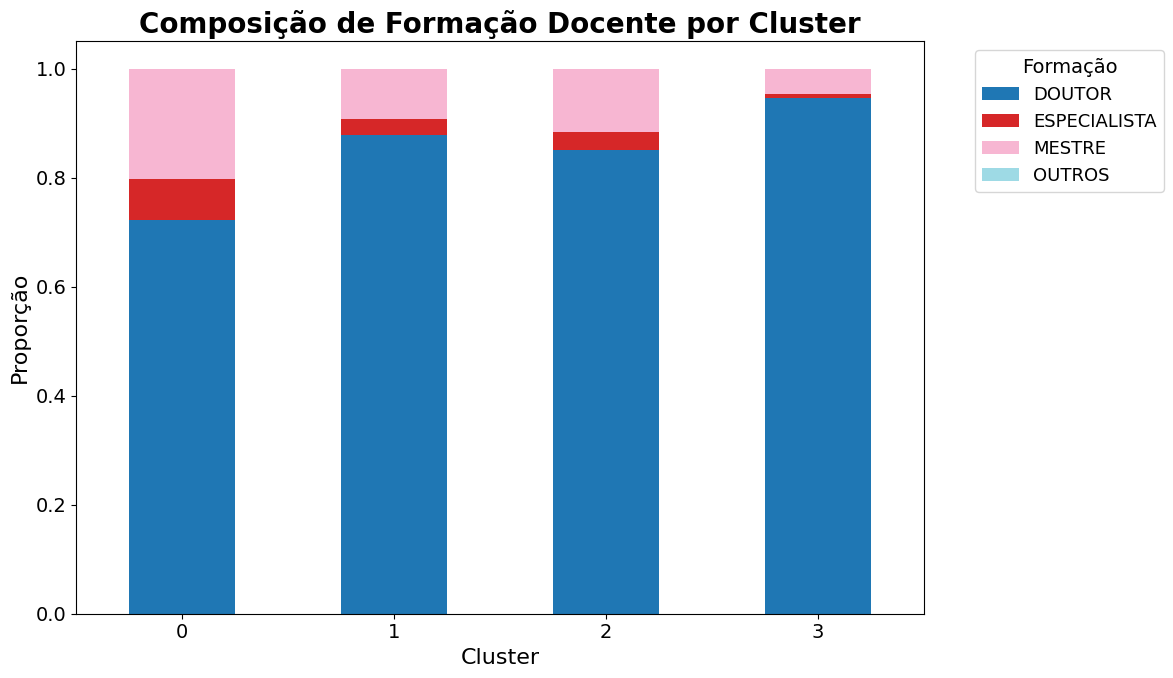

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = merged_data.copy()

# distribuição de formacao por cluster
formacao_cluster = (
    df.groupby(['cluster', 'formacao'], as_index=False)
      .size()
      .rename(columns={'size': 'count'})
)
formacao_cluster['proporcao'] = (
    formacao_cluster.groupby('cluster')['count']
    .transform(lambda x: x / x.sum())
)

print(formacao_cluster.pivot(index='formacao', columns='cluster', values='proporcao'))

# Stacked bar chart
pivot_formacao = formacao_cluster.pivot(index='cluster', columns='formacao', values='proporcao').fillna(0)

# Aumentar tamanho das fontes
plt.rcParams.update({
    'font.size': 14,           # Tamanho base da fonte
    'axes.titlesize': 18,      # Tamanho do título
    'axes.labelsize': 16,      # Tamanho dos labels dos eixos
    'xtick.labelsize': 14,     # Tamanho dos números no eixo x
    'ytick.labelsize': 14,     # Tamanho dos números no eixo y
    'legend.fontsize': 13,     # Tamanho da fonte da legenda
    'legend.title_fontsize': 14 # Tamanho do título da legenda
})

pivot_formacao.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab20')
plt.title('Composição de Formação Docente por Cluster', fontsize=20, fontweight='bold')
plt.xlabel('Cluster', fontsize=16)
plt.ylabel('Proporção', fontsize=16)
plt.legend(title='Formação', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

cluster        0         1         2         3
sexo                                          
F        0.52483  0.371692  0.473164  0.326603
M        0.47517  0.628308  0.526836  0.673397


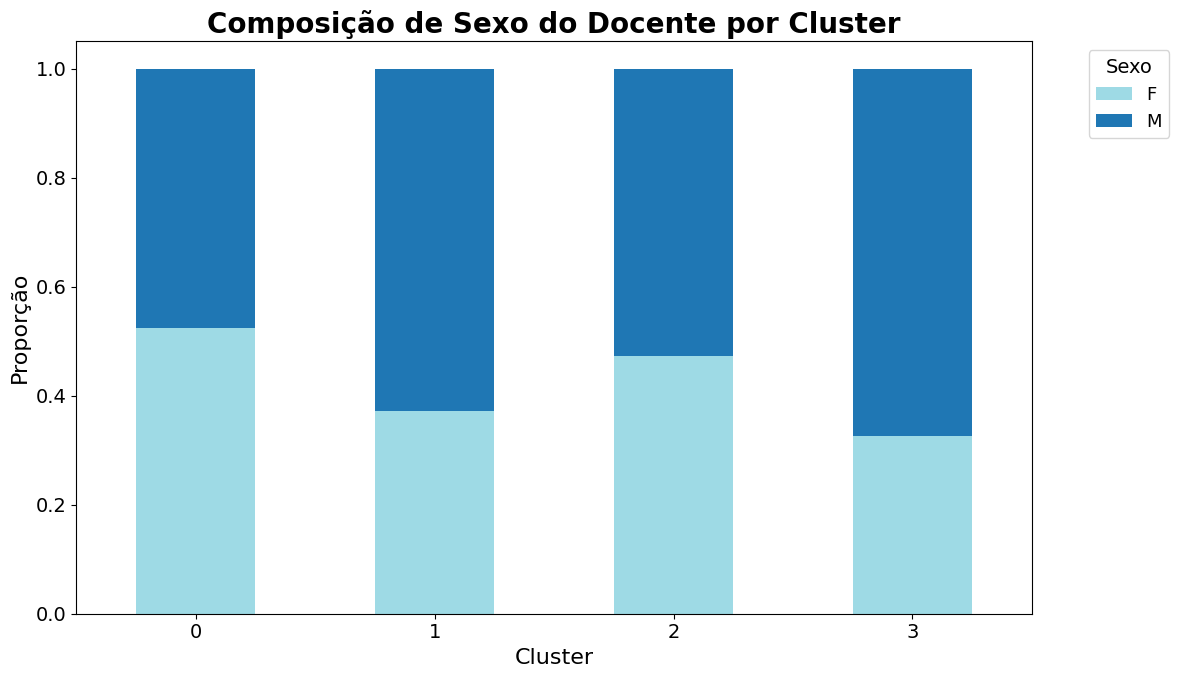

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = merged_data.copy()

# distribuição de sexo por cluster
formacao_cluster = (
    df.groupby(['cluster', 'sexo'], as_index=False)
      .size()
      .rename(columns={'size': 'count'})
)
formacao_cluster['proporcao'] = (
    formacao_cluster.groupby('cluster')['count']
    .transform(lambda x: x / x.sum())
)

print(formacao_cluster.pivot(index='sexo', columns='cluster', values='proporcao'))

# Stacked bar chart
pivot_formacao = formacao_cluster.pivot(index='cluster', columns='sexo', values='proporcao').fillna(0)

# Aumentar tamanho das fontes
plt.rcParams.update({
    'font.size': 14,           # Tamanho base da fonte
    'axes.titlesize': 18,      # Tamanho do título
    'axes.labelsize': 16,      # Tamanho dos labels dos eixos
    'xtick.labelsize': 14,     # Tamanho dos números no eixo x
    'ytick.labelsize': 14,     # Tamanho dos números no eixo y
    'legend.fontsize': 13,     # Tamanho da fonte da legenda
    'legend.title_fontsize': 14 # Tamanho do título da legenda
})

pivot_formacao.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab20_r')
plt.title('Composição de Sexo do Docente por Cluster', fontsize=20, fontweight='bold')
plt.xlabel('Cluster', fontsize=16)
plt.ylabel('Proporção', fontsize=16)
plt.legend(title='Sexo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = merged_data.copy()

# Montar dataframe com características por cluster
cluster_summary = df.groupby('cluster').agg({
    'id_turma': 'count',
    'proporcao_aprovados': 'mean',
    'qtd_discentes': 'mean',
    'media_final_geral': 'mean',
    'atuacao_profissional_media': 'mean',
    'postura_profissional_media': 'mean',
}).reset_index()

# Rename columns for better readability
cluster_summary.columns = [
    'Cluster',
    'Turmas',
    'Proporção de Aprovados',
    'Quantidade de Discentes',
    'Média Final Geral',
    'Atuação Profissional',
    'Postura Profissional'
]

# Transpose for better visualization
cluster_summary_t = cluster_summary.set_index('Cluster').T

def make_pretty(styler):
    styler.set_caption("Características Médias por Cluster")
    styler.format(precision=3)
    styler.background_gradient(axis=1, cmap="coolwarm_r")
    styler.set_properties(**{'text-align': 'center'})
    return styler

cluster_summary_t.style.pipe(make_pretty)

Cluster,0,1,2,3
Turmas,48530.000,13113.000,50678.000,13472.000
Proporção de Aprovados,0.972,0.869,0.943,0.581
Quantidade de Discentes,12.935,26.256,26.984,32.838
Média Final Geral,8.257,7.716,8.078,6.534
Atuação Profissional,9.741,8.094,9.100,8.706
Postura Profissional,9.845,7.861,9.390,9.309


In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = merged_data.copy()

# Montar dataframe com características por cluster
cluster_summary = df.groupby('cluster').agg({
    'id_turma': 'count',
    'proporcao_aprovados': 'std',
    'qtd_discentes': 'std',
    'media_final_geral': 'std',
    'atuacao_profissional_media': 'std',
    'postura_profissional_media': 'std',
}).reset_index()

# Rename columns for better readability
cluster_summary.columns = [
    'Cluster',
    'Turmas',
    'Proporção de Aprovados',
    'Quantidade de Discentes',
    'Média Final Geral',
    'Atuação Profissional',
    'Postura Profissional'
]

# Transpose for better visualization
cluster_summary_t = cluster_summary.set_index('Cluster').T

def make_pretty(styler):
    styler.set_caption("Características Médias por Cluster")
    styler.format(precision=3)
    styler.background_gradient(axis=1, cmap="coolwarm_r")
    styler.set_properties(**{'text-align': 'center'})
    return styler

cluster_summary_t.style.pipe(make_pretty)

Cluster,0,1,2,3
Turmas,48530.000,13113.000,50678.000,13472.000
Proporção de Aprovados,0.065,0.162,0.072,0.186
Quantidade de Discentes,9.718,17.427,16.367,27.385
Média Final Geral,0.900,1.066,0.946,0.821
Atuação Profissional,0.212,0.873,0.378,0.649
Postura Profissional,0.179,0.952,0.366,0.531


In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = merged_data.copy()

# Montar dataframe com características por cluster
cluster_summary = df.groupby('cluster').agg({
    'id_turma': 'count',
    'proporcao_aprovados': 'median',
    'qtd_discentes': 'median',
    'media_final_geral': 'median',
    'atuacao_profissional_media': 'median',
    'postura_profissional_media': 'median',
}).reset_index()

# Rename columns for better readability
cluster_summary.columns = [
    'Cluster',
    'Turmas',
    'Proporção de Aprovados',
    'Quantidade de Discentes',
    'Média Final Geral',
    'Atuação Profissional',
    'Postura Profissional'
]

# Transpose for better visualization
cluster_summary_t = cluster_summary.set_index('Cluster').T

def make_pretty(styler):
    styler.set_caption("Características Médias por Cluster")
    styler.format(precision=3)
    styler.background_gradient(axis=1, cmap="coolwarm_r")
    styler.set_properties(**{'text-align': 'center'})
    return styler

cluster_summary_t.style.pipe(make_pretty)

Cluster,0,1,2,3
Turmas,48530.000,13113.000,50678.000,13472.000
Proporção de Aprovados,1.000,0.921,0.971,0.615
Quantidade de Discentes,9.000,23.000,25.000,25.000
Média Final Geral,8.325,7.713,8.096,6.465
Atuação Profissional,9.770,8.250,9.150,8.780
Postura Profissional,9.900,8.080,9.450,9.430


In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = merged_data.copy()

# Montar dataframe com características por cluster
cluster_summary = df.groupby('cluster').agg({
    'id_turma': 'count',
    'proporcao_aprovados': 'max',
    'qtd_discentes': 'max',
    'media_final_geral': 'max',
    'atuacao_profissional_media': 'max',
    'postura_profissional_media': 'max',
}).reset_index()

# Rename columns for better readability
cluster_summary.columns = [
    'Cluster',
    'Turmas',
    'Proporção de Aprovados',
    'Quantidade de Discentes',
    'Média Final Geral',
    'Atuação Profissional',
    'Postura Profissional'
]

# Transpose for better visualization
cluster_summary_t = cluster_summary.set_index('Cluster').T

def make_pretty(styler):
    styler.set_caption("Características Médias por Cluster")
    styler.format(precision=3)
    styler.background_gradient(axis=1, cmap="coolwarm_r")
    styler.set_properties(**{'text-align': 'center'})
    return styler

cluster_summary_t.style.pipe(make_pretty)

Cluster,0,1,2,3
Turmas,48530.000,13113.000,50678.000,13472.000
Proporção de Aprovados,1.000,1.000,1.030,1.000
Quantidade de Discentes,72.000,176.000,306.000,306.000
Média Final Geral,10.000,10.000,10.000,10.000
Atuação Profissional,10.000,10.000,10.000,10.000
Postura Profissional,10.000,9.830,10.000,10.000


In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = merged_data.copy()

# Montar dataframe com características por cluster
cluster_summary = df.groupby('cluster').agg({
    'id_turma': 'count',
    'proporcao_aprovados': 'min',
    'qtd_discentes': 'min',
    'media_final_geral': 'min',
    'atuacao_profissional_media': 'min',
    'postura_profissional_media': 'min',
}).reset_index()

# Rename columns for better readability
cluster_summary.columns = [
    'Cluster',
    'Turmas',
    'Proporção de Aprovados',
    'Quantidade de Discentes',
    'Média Final Geral',
    'Atuação Profissional',
    'Postura Profissional'
]

# Transpose for better visualization
cluster_summary_t = cluster_summary.set_index('Cluster').T

def make_pretty(styler):
    styler.set_caption("Características Médias por Cluster")
    styler.format(precision=3)
    styler.background_gradient(axis=1, cmap="coolwarm_r")
    styler.set_properties(**{'text-align': 'center'})
    return styler

cluster_summary_t.style.pipe(make_pretty)

Cluster,0,1,2,3
Turmas,48530.000,13113.000,50678.000,13472.000
Proporção de Aprovados,0.333,0.000,0.500,0.000
Quantidade de Discentes,1.000,4.000,1.000,1.000
Média Final Geral,5.143,0.000,5.362,0.000
Atuação Profissional,8.600,0.500,6.380,2.450
Postura Profissional,8.020,0.000,7.110,5.000


In [23]:
df.groupby('cluster').describe()

id_turma                                                      \
           count          mean           std        min          25%   
cluster                                                                
0        48530.0  5.180427e+07  1.720260e+07  1207276.0  57598001.25   
1        13113.0  4.907155e+07  2.027967e+07  1207257.0  57585868.00   
2        50678.0  4.962186e+07  1.972616e+07  1207259.0  57589881.00   
3        13472.0  4.668293e+07  2.233059e+07  1207258.0  57573919.75   

                                                  ano               ...  \
                50%          75%         max    count         mean  ...   
cluster                                                             ...   
0        57638781.5  57700430.00  57740884.0  48530.0  2019.050917  ...   
1        57670408.0  57703858.00  57739299.0  13113.0  2019.278426  ...   
2        57649313.0  57699967.00  57740941.0  50678.0  2019.140041  ...   
3        57626920.5  57693474.25  57740883.0  13472.0  2018.468973  ...   

        proporcao_reprovados           id_turma.1                              \
                         75%       max      count          mean           std   
cluster                                                                         
0                   0.000000  0.666667    48530.0  5.180427e+07  1.720260e+07   
1                   0.190476  1.000000    13113.0  4.907155e+07  2.027967e+07   
2                   0.095238  0.500000    50678.0  4.962186e+07  1.972616e+07   
3                   0.533333  1.000000    13472.0  4.668293e+07  2.233059e+07   

                                                                      
               min          25%         50%          75%         max  
cluster                                                               
0        1207276.0  57598001.25  57638781.5  57700430.00  57740884.0  
1        1207257.0  57585868.00  57670408.0  57703858.00  57739299.0  
2        1207259.0  57589881.00  57649313.0  57699967.00  57740941.0  
3        1207258.0  57573919.75  57626920.5  57693474.25  57740883.0  

[4 rows x 192 columns]